<a href="https://colab.research.google.com/github/fiapostechfase1/tech-challenge/blob/Erick/Tech_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge

## 1. Descrição do Problema

<p>Imagine agora, que você vai atuar como Expert em Data Analytics em uma
empresa que exporta vinhos do Brasil para o mundo todo.
Sua área é recém-criada dentro da empresa, e você será responsável
pelos relatórios iniciais a serem apresentados em uma reunião de investidores e
acionistas, explicando a quantidade de vinhos exportados e os fatores externos
que podem vir a surgir e que interferem nas análises:</p>
<ul>
    <li>1. Dados climáticos. </li>
    <li>2. Dados demográficos.</li>
    <li>3. Dados econômicos.</li>
    <li>4. Dados de avaliações de vinhos.</li>
</ul>

<p>O Head de Dados pediu para que você construísse uma tabela contendo
as seguintes informações:</p>
<ul>
    <li>a. País de origem (Brasil). </li>
    <li>b. País de destino. </li>
    <li>c. Quantidade em litros de vinho exportado (utilize: 1KG =1L). </li>
    <li>d. Valor em US$. </li>
</ul>

<p>Os dados que lhe forneceram são de uma vinícola parceira, e podem ser
encontrados aqui: http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01
</br>Seu objetivo é dizer o montante de venda de exportação nos últimos 15
anos, separando a análise por país e trazendo quais as prospecções futuras e
possíveis ações para uma melhoria nas exportações. Construa gráficos atraentes e que passem a ideia central para que os acionistas e investidores
possam seguir em frente com suas ações.</p>

## 2. Carregando Dados

### 2.1 Importando Bibliotecas Necessárias

Inicio o projeto importando as bibliotecas que serão utilizadas para o tratamento e a visualização de dados.

In [ ]:
# importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2.2 Carregando dados

Trazendo a base de dados de exportação de vinhos para o projeto.

In [ ]:
# importando base de dados
dados = pd.read_csv('dados/ExpVinho.csv', sep = '\t')

In [ ]:
# primeira visualização da base de dados
dados.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Preparando Dados Para Análise

Nessa etapa é feita a transformação dos dados necessárias, para que os dados estejam padronizados e prontos para que sejam criadas as primeiras visualizações.

### 3.1 Visão Geral dos Dados

Entendendo melhor os dados disponíveis, e transformando-os para que possam suprir as necessidades de visualização para responder as perguntas norteadoras.

In [ ]:
# entendendo as dimensões do DataFrame
dados.shape

(141, 112)

In [ ]:
# separando colunas em lista, excluindo Id e País
colunas = dados.columns.tolist()
colunas_anos = [col for col in colunas if col not in ['Id', 'País']]

In [ ]:
# selecionando a primeira aparição de ano como Quantidade(Kg) e a segunda como Valor(US$)
colunas_quantidade = colunas_anos[::2]
colunas_valor = colunas_anos[1::2]

In [ ]:
# separando as colunas da base de dados: Quantidade
dados_quantidade = dados[['País'] + colunas_quantidade].melt(id_vars='País', var_name='Ano', value_name='Quantidade')
dados_quantidade.head()

,País,Ano,Quantidade
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [ ]:
# separando as colunas da base de dados: Valor
dados_valor = dados[['País'] + colunas_valor].copy()
dados_valor.columns = ['País'] + colunas_quantidade
dados_valor = dados_valor.melt(id_vars='País', var_name='Ano', value_name='Valor')
dados_valor.head()

,País,Ano,Valor
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [ ]:
# unificando as tabelas de Quantidade e Valor em uma única tabela
dados_final = pd.merge(dados_quantidade, dados_valor, on=['País', 'Ano'])

In [ ]:
# exibindo a tabela final
dados_final.head()

,País,Ano,Quantidade,Valor
0,Afeganistão,1970,0,0
1,África do Sul,1970,0,0
2,"Alemanha, República Democrática",1970,0,0
3,Angola,1970,0,0
4,Anguilla,1970,0,0


In [ ]:
# selecionando apenas os resultados dos últimos 15 anos com relação ao DataFrame, ou seja, entre 2010 e 2024
dados_final['Ano'] = pd.to_numeric(dados_final['Ano'], errors='coerce')
ano_max = dados_final['Ano'].max()
anos_recente = dados_final[dados_final['Ano'] >= ano_max - 14]
anos_recente.head()

,País,Ano,Quantidade,Valor
5640,Afeganistão,2010,0,0
5641,África do Sul,2010,0,0
5642,"Alemanha, República Democrática",2010,27715,138666
5643,Angola,2010,33557,189891
5644,Anguilla,2010,0,0


In [ ]:
# realizando o reset do index, para uma melhor organizazção
anos_recente.reset_index(drop = True, inplace = True)
anos_recente.head()

,País,Ano,Quantidade,Valor
0,Afeganistão,2010,0,0
1,África do Sul,2010,0,0
2,"Alemanha, República Democrática",2010,27715,138666
3,Angola,2010,33557,189891
4,Anguilla,2010,0,0


In [ ]:
# entendendo a estruturação do novo formato do DataFrame
anos_recente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115 entries, 0 to 2114
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        2115 non-null   object
 1   Ano         2115 non-null   int64 
 2   Quantidade  2115 non-null   int64 
 3   Valor       2115 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 66.2+ KB


In [ ]:
# verificando a existência de dados duplicados
anos_recente.duplicated().sum()

np.int64(0)

In [ ]:
# boxplot para compreender os outliers de cada variável
# anos_recente[['Quantidade', 'Valor']].boxplot()

In [ ]:
# analisando as estatísticas básicas
pd.set_option('display.float_format', '{:.2f}'.format)
anos_recente[['Valor', 'Quantidade']].describe()

,Valor,Quantidade
count,2115.00,2115.00
mean,54023.44,29780.27
std,483430.54,301504.14
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,3172.50,787.00
max,14795694.00,6522527.00


Por fim, a base de dados está completamente formatada e pronta para ser utilizada na visualização de dados.

## 4. Visualização dos Dados

In [ ]:
# função para plotar o valor desejado agrupado por ano
def plota_por_ano(x, ylabel, title, ylim):
    fig, ax = plt.subplots(figsize = (12, 6))
    dados_agrupados = anos_recente.groupby('Ano')[x].sum() / 1_000_000
    barras = ax.bar(dados_agrupados.index, dados_agrupados.values, color = 'blue')

    # adicionando o valor acima de cada barra
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, altura,
                f'{altura:.2f}', ha='center', va='bottom')

    ax.bar(dados_agrupados.index, dados_agrupados.values)
    ax.grid(axis = 'y')
    plt.ylim(0, ylim)
    ax.set_xlabel('Ano')
    ax.set_xticks(dados_agrupados.index)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.show()

<p>No gráfico abaixo, é possível analisar que nos últimos 15 anos durante o período de 2010 e 2011, a empresa se manteve num patamar moderado. Porém, no ano de 2012, houve um aumento disparado na produção de vinho, e 2013 teve um aumento astronômico na receita de exportação de vinhos. Isso pode ser relacionado à diversos fatores, como:</p>
<ul>
    <li><a href='https://periodicos.unicesumar.edu.br/index.php/revcesumar/article/viewFile/4395/2718?utm_source=chatgpt.com'>Uma melhora na qualidade das uvas;</a></li>
    <li><a href='https://www.idealsoftwares.com.br/indices/dolar2013.html?utm_source=chatgpt.com'>Desvalorização do real frente ao dólar.</a></li>
</ul>
<p>Existem diversos outros fatores que podem ter influenciado na exportação dos vinhos durante esse período, mas esses são os principais que tornaram o vinho brasileiro extremamente competitivo.</p>

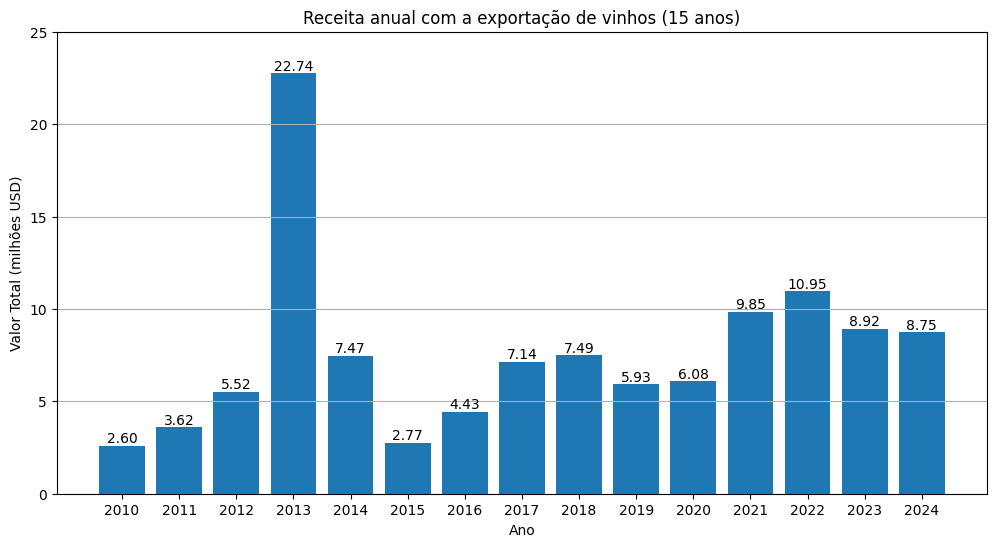

In [ ]:
# plota o campo 'Valor' por ano
plota_por_ano('Valor', 'Valor Total (milhões USD)', 'Receita anual com a exportação de vinhos (15 anos)', 25)

<p>Assim como é perceptível o grande aumento na quantidade de exportação, e na receita no período de 2013, a queda drástica no ano seguinte também é um fator intrigante. E também existem diversos fatores que podem ter influenciado nesse retrato, como:</p>

<ul>
    <li><a href='https://www.estadao.com.br/paladar/bebida/clima-extremo-reduz-safra-2014/?utm_source=chatgpt.com'>Condições climáticas desfavoráveis que resultaram em queda de 20% da produção nacional;</a></li>
    <li><a href='https://economia.uol.com.br/cotacoes/noticias/redacao/2014/12/30/dolar-sobe-13-no-ano-nos-4-anos-de-dilma-salta-60-de-r-167-a-r-266.htm?utm_source=chatgpt.com'>Aumento drástico na valorização do Dólar e incertezas políticas, podem ter gerado desconfiança do mercado internacional frente ao Brasil. </a></li>
</ul>


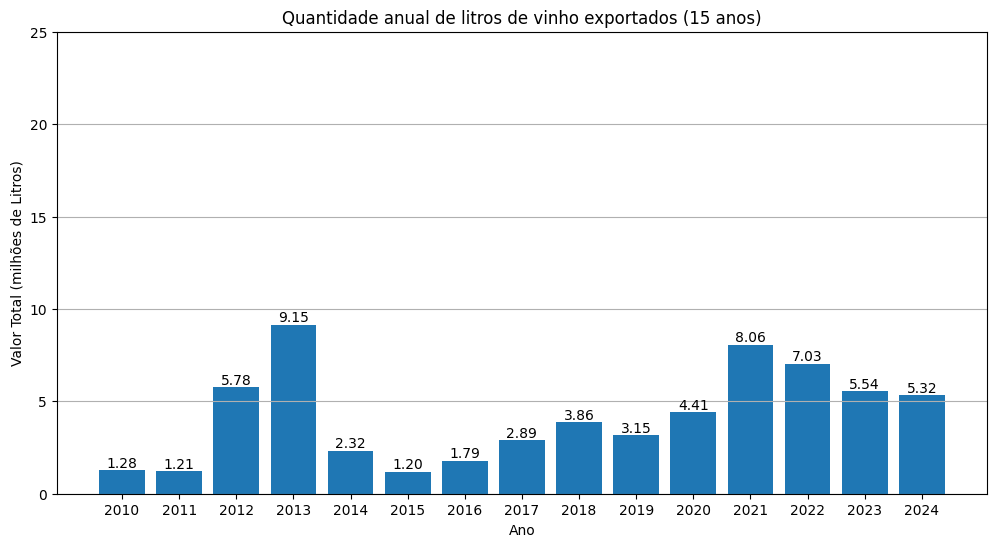

In [ ]:
plota_por_ano('Quantidade', 'Valor Total (milhões de Litros)', 'Quantidade anual de litros de vinho exportados (15 anos)', 25)

<p>Com relação a quantidade de litros de vinhos exportados, é possível analisar que à partir de 2016, houve uma retomada no crescimento da produção e nas exportações, de forma bem moderada. Isso pode ter sido produto de diversos fatores como:</p>
<ul>
    <li><a href='https://istoedinheiro.com.br/vinhos-brasileiros-da-dificil-safra-de-2016-sao-avaliados-por-especialistas/'>Piora na qualidade dos vinhos brasileiros devido a continuação de desfavorecimentos climáticos;</a></li>
    <li><a href='https://istoedinheiro.com.br/producao-mundial-de-vinho-cai-32-em-2016/'>Queda de 3,2% na produção mundial de vinhos;</a></li>
    <li><a href='https://www12.senado.leg.br/noticias/materias/2016/12/28/impeachment-de-dilma-rousseff-marca-ano-de-2016-no-congresso-e-no-brasil'>O impeachment da ex-presidente Dilma Roussef pode também ter sido uma influência, pois o ocorrido gerou grandes impactos socio-econômicos.</a></li>
</ul>

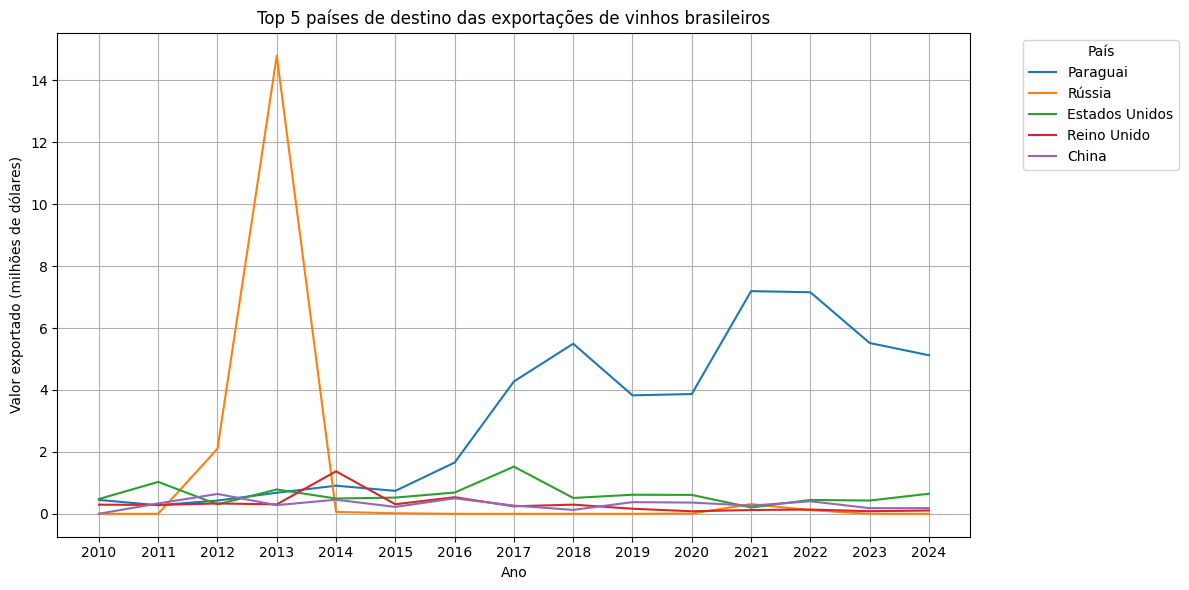

In [ ]:
# Calcular o total exportado por país
top_5_paises = (
    anos_recente.groupby('País')['Valor'].sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filtrar os dados para conter apenas os top 5 países
top_df = anos_recente[anos_recente['País'].isin(top_5_paises)]

# Criar a tabela pivot
df_pivot = top_df.pivot_table(index='Ano', columns='País', values='Valor', aggfunc='sum')
df_pivot = df_pivot / 1_000_000  # transformar em milhões

# Ordenar colunas pelo total exportado (da maior para a menor)
ordem_colunas = df_pivot.sum().sort_values(ascending=False).index
df_pivot = df_pivot[ordem_colunas]

# Plotar
fig, ax = plt.subplots(figsize=(12, 6))
df_pivot.plot(ax=ax)

# Ticks para todos os anos
ax.set_xticks(df_pivot.index)

ax.set(
    xlabel='Ano',
    ylabel='Valor exportado (milhões de dólares)',
    title='Top 5 países de destino das exportações de vinhos brasileiros'
)
ax.grid()

# Legenda ordenada
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='País', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Conclusão

<p>O desempenho das exportações de vinhos brasileiros entre 2013 e os anos seguintes revela como o setor é altamente sensível a fatores externos e internos. O pico em 2013 pode ser atribuído à combinação de uma safra de alta qualidade e à desvalorização do real frente ao dólar, que tornou o produto brasileiro mais competitivo no mercado internacional

A partir de 2014, no entanto, a instabilidade começou a impactar o setor: uma safra prejudicada por condições climáticas extremas reduziu a produção em cerca de 20%, enquanto o agravamento do cenário político e econômico elevou a incerteza no comércio exterior.

Em 2016, o impacto do impeachment da presidente Dilma Rousseff adicionou uma camada de instabilidade política e econômica ao país. Esse processo gerou turbulências nos mercados e pode ter influenciado negativamente a percepção internacional sobre o Brasil. Nesse mesmo ano, houve um aumento bem moderado na quantidade exportada, possivelmente devido a uma piora na qualidade do vinho — reflexo das condições climáticas desfavoráveis e da queda global na produção de vinho.

O cenário pós-2016 revela um setor tentando se recuperar, mas que ainda sofre com as consequências desses fatores.
Os resuldos dos últimos anos demonstram que o setor vitivinícola brasileiro passou a produzir mais, e obter um menor retorno com base na quantidade de litros exportados. Isso evidencia a necessidade de estratégias que agreguem mais valor ao produto nacional, como a qualificação técnica das vinícolas, fortalecimento da imagem do vinho brasileiro no exterior e maior estabilidade econômica e política.</p>